In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Primeira inspeção dos dados

Nesta etapa, será realizada uma inspeção inicial do conjunto de dados para conhecer suas dimensões, colunas, tipos de dados e possíveis valores ausentes.

In [3]:
df.shape
print(f"O conjunto de dados possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O conjunto de dados possui 891 linhas e 12 colunas.


In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Análise de valores ausentes

Valores ausentes podem afetar cálculos, gráficos e modelos de Machine Learning. Por isso, é importante identificar sua quantidade antes de decidir como tratá-los.

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
valores_ausentes = df.isnull().sum()

porcentagem_ausentes = (
    valores_ausentes / len(df) * 100
).round(2)

analise_ausentes = pd.DataFrame({
    "Quantidade": valores_ausentes,
    "Porcentagem (%)": porcentagem_ausentes
})

analise_ausentes

,Quantidade,Porcentagem (%)
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [8]:
analise_ausentes[
    analise_ausentes["Quantidade"] > 0
].sort_values(by="Quantidade", ascending=False)

,Quantidade,Porcentagem (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### Interpretação

Foram identificados valores ausentes em três variáveis:

- `Cabin`: 687 valores ausentes, aproximadamente 77,10% dos registros;
- `Age`: 177 valores ausentes, aproximadamente 19,87%;
- `Embarked`: 2 valores ausentes, aproximadamente 0,22%.

A variável `Cabin` exige maior atenção devido à alta proporção de dados ausentes.

In [9]:
df.duplicated().sum()

np.int64(0)

### Registros duplicados

Não foram identificadas linhas completamente duplicadas no conjunto de dados.

## Estatísticas descritivas

Nesta etapa, serão analisadas medidas como média, desvio padrão, valores mínimos, máximos e quartis das variáveis numéricas.

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Interpretação das idades

A idade média dos passageiros foi de aproximadamente **29,70 anos**, enquanto a mediana foi de **28 anos**. A menor idade registrada foi de **0,42 ano**, e a maior foi de **80 anos**.

A proximidade entre a média e a mediana sugere que a distribuição das idades pode não apresentar uma assimetria muito intensa. Entretanto, será necessário analisar sua distribuição graficamente.

In [11]:
df.describe(include=[str])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


### Análise das variáveis categóricas

O conjunto de dados possui 891 nomes únicos. A maioria dos passageiros registrados é do sexo masculino, com 577 ocorrências.

Foram identificados 681 números de passagem diferentes, indicando que alguns passageiros compartilhavam o mesmo ticket. A variável `Cabin` possui apenas 204 valores preenchidos, confirmando sua elevada proporção de dados ausentes.

O porto de embarque mais frequente foi `S`, com 644 passageiros.

## Análise da sobrevivência

Nesta etapa, será analisada a quantidade e a proporção de passageiros que sobreviveram ou não ao naufrágio.

In [12]:
df["Survived"].value_counts().sort_index()

Survived
0    549
1    342
Name: count, dtype: int64

In [13]:
df["Survived"].value_counts(
    normalize=True
).sort_index().mul(100).round(2)

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

In [14]:
quantidade_sobrevivencia = (
    df["Survived"]
    .value_counts()
    .sort_index()
)

percentual_sobrevivencia = (
    df["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

analise_sobrevivencia = pd.DataFrame({
    "Quantidade": quantidade_sobrevivencia,
    "Percentual (%)": percentual_sobrevivencia
})

analise_sobrevivencia.index = [
    "Não sobreviveu",
    "Sobreviveu"
]

analise_sobrevivencia

,Quantidade,Percentual (%)
Não sobreviveu,549,61.62
Sobreviveu,342,38.38


### Interpretação

Dos 891 passageiros registrados, 342 sobreviveram, representando **38,38%** do total. Outros 549 passageiros não sobreviveram, correspondendo a **61,62%**.

Portanto, a quantidade de passageiros que não sobreviveram foi consideravelmente maior que a quantidade de sobreviventes.

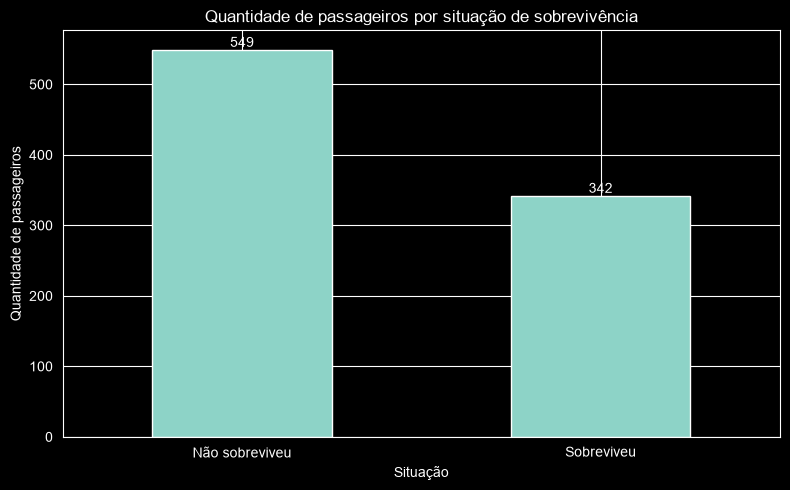

In [15]:
ax = quantidade_sobrevivencia.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Quantidade de passageiros por situação de sobrevivência")
plt.xlabel("Situação")
plt.ylabel("Quantidade de passageiros")

plt.xticks(
    ticks=[0, 1],
    labels=["Não sobreviveu", "Sobreviveu"],
    rotation=0
)

ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

### Interpretação do gráfico

O gráfico mostra que a maioria dos passageiros não sobreviveu ao naufrágio. Foram registrados 549 não sobreviventes e 342 sobreviventes, correspondendo a uma taxa de sobrevivência de 38,38%.

## Sobrevivência por sexo

Nesta etapa, será analisada a relação entre o sexo dos passageiros e a taxa de sobrevivência.

In [16]:
sobrevivencia_por_sexo = pd.crosstab(
    df["Sex"],
    df["Survived"]
)

sobrevivencia_por_sexo.columns = [
    "Não sobreviveu",
    "Sobreviveu"
]

sobrevivencia_por_sexo

,Não sobreviveu,Sobreviveu
Sex,,
female,81,233
male,468,109


In [17]:
taxa_sobrevivencia_por_sexo = (
    df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

taxa_sobrevivencia_por_sexo

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

### Interpretação

A taxa de sobrevivência das mulheres foi de aproximadamente **74,20%**, enquanto a dos homens foi de apenas **18,89%**.

Os resultados indicam uma forte associação entre o sexo do passageiro e a sobrevivência. Mulheres apresentaram uma probabilidade de sobrevivência consideravelmente maior que os homens.

## Sobrevivência por classe

Nesta etapa, será analisada a relação entre a classe da passagem e a taxa de sobrevivência dos passageiros.

In [18]:
sobrevivencia_por_classe = pd.crosstab(
    df["Pclass"],
    df["Survived"]
)

sobrevivencia_por_classe.columns = [
    "Não sobreviveu",
    "Sobreviveu"
]

sobrevivencia_por_classe.index = [
    "1ª classe",
    "2ª classe",
    "3ª classe"
]

sobrevivencia_por_classe

,Não sobreviveu,Sobreviveu
1ª classe,80,136
2ª classe,97,87
3ª classe,372,119


In [19]:
taxa_sobrevivencia_por_classe = (
    df.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

taxa_sobrevivencia_por_classe.index = [
    "1ª classe",
    "2ª classe",
    "3ª classe"
]

taxa_sobrevivencia_por_classe

1ª classe    62.96
2ª classe    47.28
3ª classe    24.24
Name: Survived, dtype: float64

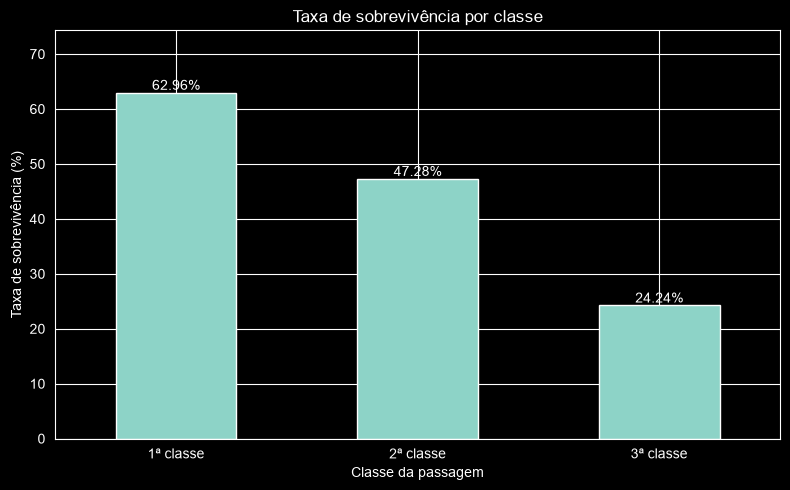

In [20]:
ax = taxa_sobrevivencia_por_classe.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Taxa de sobrevivência por classe")
plt.xlabel("Classe da passagem")
plt.ylabel("Taxa de sobrevivência (%)")
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%"
)

plt.ylim(
    0,
    taxa_sobrevivencia_por_classe.max() * 1.18
)

plt.tight_layout()
plt.show()

### Interpretação

A primeira classe apresentou a maior taxa de sobrevivência, com aproximadamente **62,96%**, seguida pela segunda classe, com **47,28%**. A terceira classe teve a menor taxa, com cerca de **24,24%**.

Os resultados indicam uma associação entre a classe da passagem e a sobrevivência: passageiros de classes mais altas apresentaram taxas de sobrevivência maiores.

## Análise das idades

Nesta etapa, será analisada a distribuição das idades dos passageiros e sua possível relação com a sobrevivência.

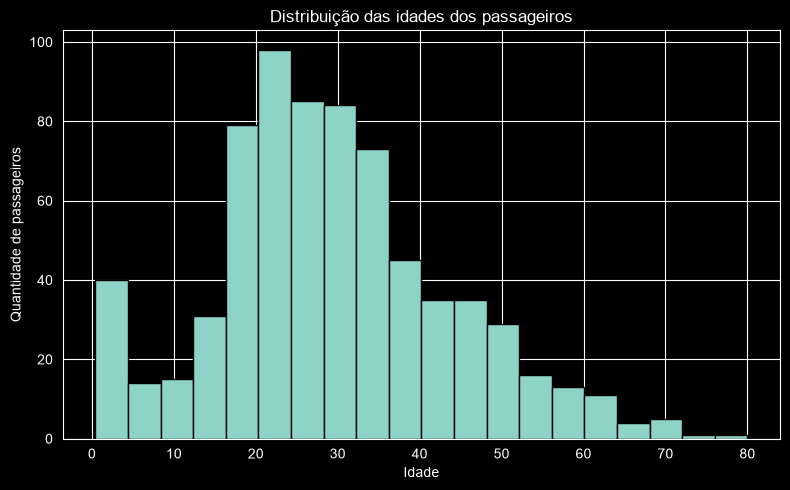

In [21]:
ax = df["Age"].plot(
    kind="hist",
    bins=20,
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Distribuição das idades dos passageiros")
plt.xlabel("Idade")
plt.ylabel("Quantidade de passageiros")
plt.tight_layout()
plt.show()

### Interpretação da distribuição das idades

A maior parte dos passageiros tinha entre aproximadamente **18 e 35 anos**, com maior concentração na faixa dos 20 anos.

A quantidade de passageiros diminui progressivamente nas faixas etárias mais elevadas, sendo pouco frequentes os registros de pessoas acima de 60 anos. Também foram registrados bebês e crianças no conjunto de dados.

A distribuição apresenta uma concentração maior nas idades mais jovens e uma extensão em direção às idades mais elevadas.

In [22]:
idade_por_sobrevivencia = (
    df.groupby("Survived")["Age"]
    .agg(["count", "mean", "median"])
    .round(2)
)

idade_por_sobrevivencia.index = [
    "Não sobreviveu",
    "Sobreviveu"
]

idade_por_sobrevivencia

,count,mean,median
Não sobreviveu,424,30.63,28.0
Sobreviveu,290,28.34,28.0


In [23]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 80],
    labels=[
        "Criança",
        "Adolescente",
        "Adulto jovem",
        "Adulto",
        "Idoso"
    ],
    include_lowest=True
)

In [24]:
taxa_sobrevivencia_por_idade = (
    df.groupby(
        "AgeGroup",
        observed=False
    )["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

taxa_sobrevivencia_por_idade

AgeGroup
Criança         57.97
Adolescente     42.86
Adulto jovem    38.27
Adulto          40.00
Idoso           22.73
Name: Survived, dtype: float64

### Interpretação da sobrevivência por faixa etária

As crianças apresentaram a maior taxa de sobrevivência, com aproximadamente **57,97%**. Em contraste, os idosos tiveram a menor taxa, com cerca de **22,73%**.

Adolescentes, adultos jovens e adultos apresentaram taxas entre aproximadamente 38% e 43%.

Os resultados sugerem uma associação entre a faixa etária e a sobrevivência. Entretanto, essa relação também pode ser influenciada por outras características, como sexo e classe da passagem.

É importante considerar que 177 passageiros não possuem idade registrada e, portanto, não foram incluídos nesta análise por faixa etária.

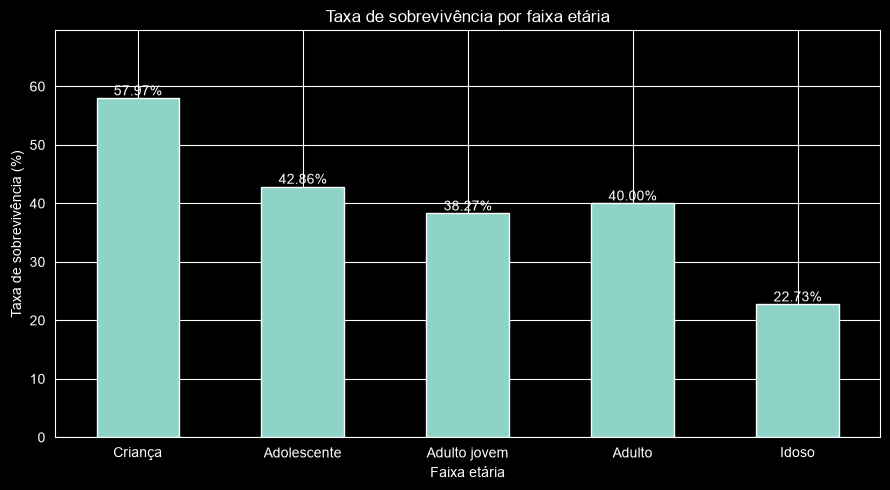

In [25]:
ax = taxa_sobrevivencia_por_idade.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Taxa de sobrevivência por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Taxa de sobrevivência (%)")
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%"
)

plt.ylim(
    0,
    taxa_sobrevivencia_por_idade.max() * 1.20
)

plt.tight_layout()
plt.show()

## Relação entre tarifa e sobrevivência

Nesta etapa, será analisada a relação entre o valor pago pela passagem, representado pela variável `Fare`, e a sobrevivência dos passageiros.

Serão comparadas medidas como média, mediana, valor mínimo e valor máximo das tarifas entre sobreviventes e não sobreviventes. Também será utilizado um boxplot para observar a distribuição dos valores e identificar possíveis valores extremos.

Como a tarifa estava relacionada à classe da passagem, os resultados devem ser interpretados com cautela, pois passageiros que pagaram valores mais altos geralmente viajavam em classes superiores.

In [26]:
tarifa_por_sobrevivencia = (
    df.groupby("Survived")["Fare"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

tarifa_por_sobrevivencia.index = [
    "Não sobreviveu",
    "Sobreviveu"
]

tarifa_por_sobrevivencia

,count,mean,median,min,max
Não sobreviveu,549,22.12,10.5,0.0,263.00
Sobreviveu,342,48.40,26.0,0.0,512.33


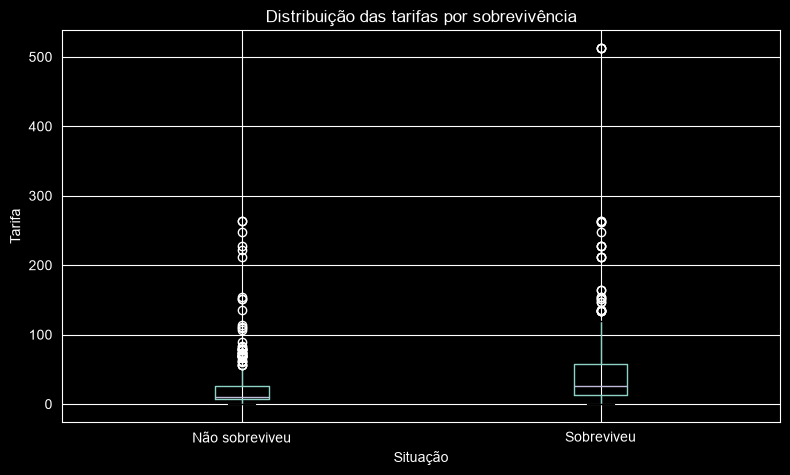

In [27]:
df.boxplot(
    column="Fare",
    by="Survived",
    figsize=(8, 5)
)

plt.title("Distribuição das tarifas por sobrevivência")
plt.suptitle("")
plt.xlabel("Situação")
plt.ylabel("Tarifa")
plt.xticks(
    ticks=[1, 2],
    labels=["Não sobreviveu", "Sobreviveu"]
)
plt.tight_layout()
plt.show()

### Interpretação das tarifas

Os passageiros sobreviventes apresentaram tarifas média e mediana superiores às dos passageiros que não sobreviveram.

Isso sugere uma associação entre o valor da passagem e a sobrevivência. Entretanto, essa relação provavelmente também está ligada à classe da passagem, pois passageiros das classes superiores geralmente pagavam tarifas maiores.

A variável `Fare` apresenta valores extremos, fazendo com que a média seja consideravelmente maior que a mediana.

## Relação entre porto de embarque e sobrevivência

Nesta etapa, será analisada a relação entre o porto de embarque dos passageiros, representado pela variável `Embarked`, e a taxa de sobrevivência.

Os códigos utilizados no conjunto de dados correspondem aos seguintes portos:

- `C`: Cherbourg;
- `Q`: Queenstown;
- `S`: Southampton.

Serão comparadas as quantidades de sobreviventes e não sobreviventes em cada porto, além da taxa de sobrevivência de cada grupo.

Os resultados devem ser interpretados com cautela, pois o porto de embarque pode estar relacionado a outras características dos passageiros, como classe da passagem e valor da tarifa.

In [28]:
sobrevivencia_por_embarque = pd.crosstab(
    df["Embarked"],
    df["Survived"]
)

sobrevivencia_por_embarque.columns = [
    "Não sobreviveu",
    "Sobreviveu"
]

sobrevivencia_por_embarque.index = [
    "Cherbourg",
    "Queenstown",
    "Southampton"
]

sobrevivencia_por_embarque

,Não sobreviveu,Sobreviveu
Cherbourg,75,93
Queenstown,47,30
Southampton,427,217


In [29]:
taxa_sobrevivencia_por_embarque = (
    df.groupby("Embarked")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

taxa_sobrevivencia_por_embarque.index = [
    "Cherbourg",
    "Queenstown",
    "Southampton"
]

taxa_sobrevivencia_por_embarque

Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: Survived, dtype: float64

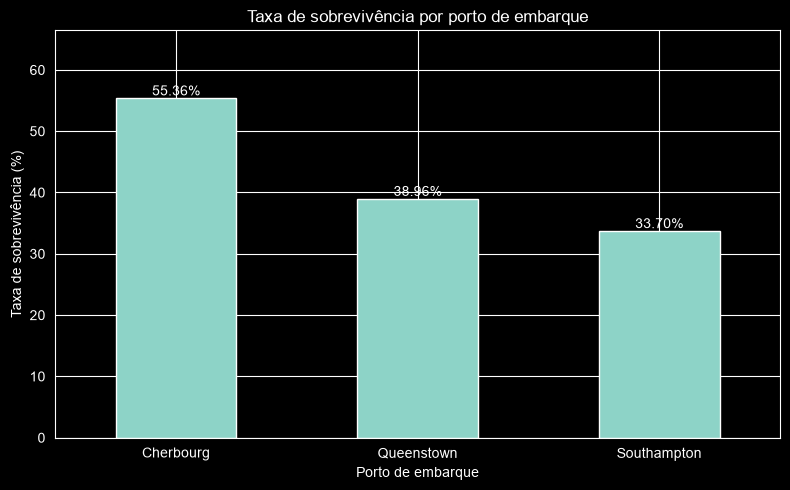

In [30]:
ax = taxa_sobrevivencia_por_embarque.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Taxa de sobrevivência por porto de embarque")
plt.xlabel("Porto de embarque")
plt.ylabel("Taxa de sobrevivência (%)")
plt.xticks(rotation=0)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%"
)

plt.ylim(
    0,
    taxa_sobrevivencia_por_embarque.max() * 1.20
)

plt.tight_layout()
plt.show()

### Interpretação

Os passageiros que embarcaram em **Cherbourg** apresentaram a maior taxa de sobrevivência, com aproximadamente **55,36%**. Em seguida, ficaram os passageiros de **Queenstown**, com cerca de **38,96%**, enquanto os passageiros que embarcaram em **Southampton** tiveram a menor taxa, aproximadamente **33,70%**.

Os resultados indicam uma associação entre o porto de embarque e a sobrevivência. Entretanto, não é possível afirmar que o porto, isoladamente, tenha causado essa diferença.

Uma possível explicação é que o porto de embarque também estava relacionado a outras características, como a classe da passagem e o valor pago. Passageiros que embarcaram em Cherbourg podem ter viajado com maior frequência nas classes superiores, que também apresentaram taxas de sobrevivência mais elevadas.

Além disso, dois passageiros não possuem informação de porto de embarque e não foram incluídos nessa comparação.

## Conclusões

A análise exploratória foi realizada com 891 registros de passageiros do Titanic.

A taxa geral de sobrevivência foi de aproximadamente **38,38%**, indicando que a maioria dos passageiros registrados não sobreviveu.

As principais conclusões foram:

- Mulheres apresentaram uma taxa de sobrevivência consideravelmente maior que os homens.
- Passageiros da primeira classe tiveram maior taxa de sobrevivência, enquanto os da terceira classe apresentaram a menor.
- Crianças tiveram a maior taxa de sobrevivência entre as faixas etárias analisadas.
- Passageiros que pagaram tarifas mais elevadas apresentaram maior sobrevivência, embora essa relação também esteja associada à classe da passagem.
- Passageiros que embarcaram em Cherbourg apresentaram a maior taxa de sobrevivência.
- A coluna `Cabin` possui aproximadamente 77% de valores ausentes.
- A coluna `Age` possui aproximadamente 20% de valores ausentes.
- Não foram encontradas linhas completamente duplicadas.

Os resultados indicam que características como sexo, classe da passagem, idade, tarifa e porto de embarque estavam associadas à sobrevivência.

Entretanto, esta análise é exploratória e não permite afirmar que essas variáveis, isoladamente, causaram a sobrevivência. Algumas delas estão relacionadas entre si, como classe da passagem e tarifa.

Como próxima etapa, os dados poderão ser preparados para a construção de um modelo de Machine Learning capaz de prever a sobrevivência dos passageiros.